In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/datasets/kmader/skin-

In [11]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import json
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {torch.cuda.get_device_name(0)}")

# Verify HAM10000 is attached
HAM_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

print(f"\nHAM10000 contents:")
for item in os.listdir(HAM_PATH):
    full = os.path.join(HAM_PATH, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"  [DIR]  {item}/  ({count} files)")
    else:
        size = os.path.getsize(full) / (1024*1024)
        print(f"  [FILE] {item}  ({size:.1f} MB)")

✓ Device: Tesla T4

HAM10000 contents:
  [FILE] hmnist_8_8_RGB.csv  (7.2 MB)
  [FILE] hmnist_28_28_RGB.csv  (87.6 MB)
  [DIR]  HAM10000_images_part_1/  (5000 files)
  [DIR]  ham10000_images_part_1/  (5000 files)
  [FILE] hmnist_8_8_L.csv  (2.4 MB)
  [DIR]  HAM10000_images_part_2/  (5015 files)
  [DIR]  ham10000_images_part_2/  (5015 files)
  [FILE] hmnist_28_28_L.csv  (29.4 MB)
  [FILE] HAM10000_metadata.csv  (0.5 MB)


HAM10000 OVERVIEW
Total samples    : 10015
Unique diseases  : 7

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


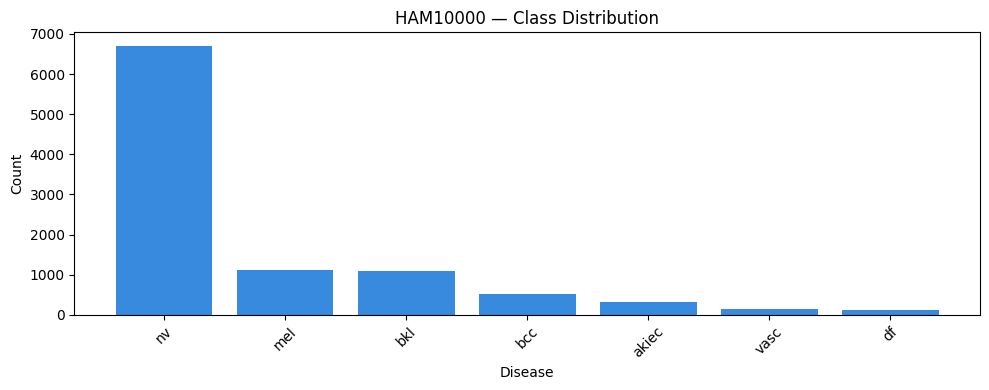

✓ Distribution plot saved


In [12]:
# Load metadata
meta = pd.read_csv(f"{HAM_PATH}/HAM10000_metadata.csv")

print("=" * 50)
print("HAM10000 OVERVIEW")
print("=" * 50)
print(f"Total samples    : {len(meta)}")
print(f"Unique diseases  : {meta['dx'].nunique()}")
print(f"\nClass distribution:")
print(meta['dx'].value_counts())

# Map disease codes to full names
dx_map = {
    'nv'  : 'Melanocytic nevi',
    'mel' : 'Melanoma',
    'bkl' : 'Benign keratosis',
    'bcc' : 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df'  : 'Dermatofibroma'
}
meta['dx_full'] = meta['dx'].map(dx_map)

# Plot class distribution
plt.figure(figsize=(10, 4))
counts = meta['dx'].value_counts()
plt.bar(counts.index, counts.values, color='#378ADD')
plt.title('HAM10000 — Class Distribution')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/kaggle/working/ham10000_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Distribution plot saved")

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Find all images
img_dir1 = f"{HAM_PATH}/HAM10000_images_part_1"
img_dir2 = f"{HAM_PATH}/HAM10000_images_part_2"

# Build full path for each image
def find_image_path(image_id):
    for d in [img_dir1, img_dir2]:
        path = os.path.join(d, f"{image_id}.jpg")
        if os.path.exists(path):
            return path
    return None

print("Building image paths...")
meta['image_path'] = meta['image_id'].apply(find_image_path)
missing = meta['image_path'].isna().sum()
print(f"✓ Paths built")
print(f"  Found   : {meta['image_path'].notna().sum()}")
print(f"  Missing : {missing}")

# Encode labels
le = LabelEncoder()
meta['label'] = le.fit_transform(meta['dx'])
NUM_CLASSES = len(le.classes_)
print(f"  Classes : {NUM_CLASSES}")
print(f"  Labels  : {list(le.classes_)}")

# ── 5-10% CLASS-WISE SAMPLER ──────────────────────────────────
def sample_per_class(df, frac=0.10, min_samples=3):
    sampled = []
    for cls in df['dx'].unique():
        cls_df = df[df['dx'] == cls]
        n      = max(min_samples, int(len(cls_df) * frac))
        n      = min(n, len(cls_df))
        sampled.append(cls_df.sample(n=n, random_state=42))
    return pd.concat(sampled).reset_index(drop=True)

# Drop missing paths
meta_clean = meta.dropna(
    subset=['image_path']).reset_index(drop=True)

# Create splits
exp1_train = sample_per_class(meta_clean, frac=0.10)
remaining  = meta_clean[
    ~meta_clean['image_id'].isin(exp1_train['image_id'])
].reset_index(drop=True)

# 80/20 split for full dataset
full_train, full_test = train_test_split(
    meta_clean, test_size=0.2,
    random_state=42, stratify=meta_clean['dx']
)
full_train = full_train.reset_index(drop=True)
full_test  = full_test.reset_index(drop=True)

# Use remaining as test for exp1
exp1_test = remaining.copy()

print(f"\n✓ Splits ready")
print(f"  Exp1 train (5-10%) : {len(exp1_train)} samples")
print(f"  Exp1 test          : {len(exp1_test)} samples")
print(f"  Full train         : {len(full_train)} samples")
print(f"  Full test          : {len(full_test)} samples")
print(f"\nExp1 class distribution:")
print(exp1_train['dx'].value_counts())

Building image paths...
✓ Paths built
  Found   : 10015
  Missing : 0
  Classes : 7
  Labels  : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

✓ Splits ready
  Exp1 train (5-10%) : 998 samples
  Exp1 test          : 9017 samples
  Full train         : 8012 samples
  Full test          : 2003 samples

Exp1 class distribution:
dx
nv       670
mel      111
bkl      109
bcc       51
akiec     32
vasc      14
df        11
Name: count, dtype: int64


In [14]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['image_path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
        except:
            img = torch.zeros(3, 224, 224)
        return {
            'image': img,
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Exp1 datasets (5-10% scarcity)
exp1_train_ds = HAMDataset(exp1_train, train_transform)
exp1_test_ds  = HAMDataset(exp1_test,  test_transform)

exp1_train_loader = DataLoader(exp1_train_ds, batch_size=32,
                                shuffle=True,  num_workers=4)
exp1_test_loader  = DataLoader(exp1_test_ds,  batch_size=32,
                                shuffle=False, num_workers=4)

print(f"✓ Exp1 DataLoaders ready")
print(f"  Train samples : {len(exp1_train_ds)}")
print(f"  Test samples  : {len(exp1_test_ds)}")
print(f"  Train batches : {len(exp1_train_loader)}")

✓ Exp1 DataLoaders ready
  Train samples : 998
  Test samples  : 9017
  Train batches : 32


In [15]:
import torchvision.models as models
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.4):
        super().__init__()
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1)
        for layer in list(backbone.children())[:-3]:
            for param in layer.parameters():
                param.requires_grad = False
        self.features   = nn.Sequential(
            *list(backbone.children())[:-1])
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

EPOCHS   = 15
model    = ResNet50Classifier(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=0.01
)
scheduler = CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

train_losses = []
train_accs   = []

print(f"Training on 5-10% HAM10000 — {EPOCHS} epochs")
print(f"  Train samples : {len(exp1_train_ds)}")
print(f"  Classes       : {NUM_CLASSES}")
print("-" * 55)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in exp1_train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler.step()
    avg_loss = total_loss / len(exp1_train_loader)
    acc      = correct / total * 100
    train_losses.append(avg_loss)
    train_accs.append(acc)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {acc:.2f}%")

print("-" * 55)
print("✓ Training complete")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s] 


Training on 5-10% HAM10000 — 15 epochs
  Train samples : 998
  Classes       : 7
-------------------------------------------------------
Epoch 01/15 | Loss: 1.8505 | Train Acc: 33.47%
Epoch 02/15 | Loss: 1.4140 | Train Acc: 62.12%
Epoch 03/15 | Loss: 1.1132 | Train Acc: 72.04%
Epoch 04/15 | Loss: 0.9141 | Train Acc: 76.15%
Epoch 05/15 | Loss: 0.7684 | Train Acc: 78.76%
Epoch 06/15 | Loss: 0.7300 | Train Acc: 81.86%
Epoch 07/15 | Loss: 0.5199 | Train Acc: 85.07%
Epoch 08/15 | Loss: 0.4332 | Train Acc: 88.18%
Epoch 09/15 | Loss: 0.3804 | Train Acc: 88.88%
Epoch 10/15 | Loss: 0.2979 | Train Acc: 92.69%
Epoch 11/15 | Loss: 0.2926 | Train Acc: 92.79%
Epoch 12/15 | Loss: 0.2586 | Train Acc: 92.89%
Epoch 13/15 | Loss: 0.2289 | Train Acc: 93.79%
Epoch 14/15 | Loss: 0.2183 | Train Acc: 94.49%
Epoch 15/15 | Loss: 0.1980 | Train Acc: 95.49%
-------------------------------------------------------
✓ Training complete


In [16]:
def evaluate_topk(model, loader, device, k=5):
    model.eval()
    all_preds, all_labels = [], []
    top5_correct, total   = 0, 0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(device)
            labels = batch['label'].to(device)
            logits = model(images)

            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Top-K (use min of k and num_classes)
            k_actual = min(k, logits.size(1))
            topk = logits.topk(k_actual, dim=1).indices
            for i, lbl in enumerate(labels):
                if lbl in topk[i]:
                    top5_correct += 1
            total += labels.size(0)

    return {
        "accuracy"     : round(accuracy_score(
                            all_labels, all_preds)*100, 2),
        "f1_macro"     : round(f1_score(
                            all_labels, all_preds,
                            average='macro',
                            zero_division=0)*100, 2),
        "f1_weighted"  : round(f1_score(
                            all_labels, all_preds,
                            average='weighted',
                            zero_division=0)*100, 2),
        "top5_accuracy": round(top5_correct/total*100, 2),
        "total_samples": total
    }

# Evaluate Exp1
print("Evaluating Exp1 (5-10% scarcity)...")
exp1_metrics = evaluate_topk(model, exp1_test_loader, device)

print("\n" + "=" * 55)
print("EXP 1 — HAM10000 BASELINE (5-10% scarcity)")
print("=" * 55)
print(f"  Accuracy     : {exp1_metrics['accuracy']}%")
print(f"  F1 Macro     : {exp1_metrics['f1_macro']}%")
print(f"  F1 Weighted  : {exp1_metrics['f1_weighted']}%")
print(f"  Top-5 Acc    : {exp1_metrics['top5_accuracy']}%")
print(f"  Test samples : {exp1_metrics['total_samples']}")

# Save exp1 model
torch.save({
    'model_state_dict': model.state_dict(),
    'le_classes'      : list(le.classes_),
    'metrics'         : exp1_metrics
}, '/kaggle/working/ham_exp1_baseline.pt')
print(f"\n✓ Exp1 model saved")

Evaluating Exp1 (5-10% scarcity)...

EXP 1 — HAM10000 BASELINE (5-10% scarcity)
  Accuracy     : 77.59%
  F1 Macro     : 55.45%
  F1 Weighted  : 77.24%
  Top-5 Acc    : 94.8%
  Test samples : 9017

✓ Exp1 model saved


In [17]:
# Full dataset DataLoaders
full_train_ds = HAMDataset(full_train, train_transform)
full_test_ds  = HAMDataset(full_test,  test_transform)

full_train_loader = DataLoader(full_train_ds, batch_size=32,
                                shuffle=True,  num_workers=4)
full_test_loader  = DataLoader(full_test_ds,  batch_size=32,
                                shuffle=False, num_workers=4)

# New model for full training
model_full = ResNet50Classifier(NUM_CLASSES).to(device)
optimizer2 = AdamW(
    filter(lambda p: p.requires_grad, model_full.parameters()),
    lr=1e-4, weight_decay=0.01
)
scheduler2 = CosineAnnealingLR(
    optimizer2, T_max=EPOCHS, eta_min=1e-6)

full_losses = []
full_accs   = []

print(f"Training on FULL HAM10000 — {EPOCHS} epochs")
print(f"  Train samples : {len(full_train_ds)}")
print("-" * 55)

for epoch in range(EPOCHS):
    model_full.train()
    total_loss, correct, total = 0, 0, 0

    for batch in full_train_loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer2.zero_grad()
        logits = model_full(images)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_full.parameters(), 1.0)
        optimizer2.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    scheduler2.step()
    avg_loss = total_loss / len(full_train_loader)
    acc      = correct / total * 100
    full_losses.append(avg_loss)
    full_accs.append(acc)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Train Acc: {acc:.2f}%")

print("-" * 55)
print("✓ Full training complete")

# Evaluate full model
print("\nEvaluating full dataset model...")
full_metrics = evaluate_topk(
    model_full, full_test_loader, device)

print("\n" + "=" * 55)
print("EXP 3 — HAM10000 UPPER BOUND (Full Dataset)")
print("=" * 55)
print(f"  Accuracy     : {full_metrics['accuracy']}%")
print(f"  F1 Macro     : {full_metrics['f1_macro']}%")
print(f"  F1 Weighted  : {full_metrics['f1_weighted']}%")
print(f"  Top-5 Acc    : {full_metrics['top5_accuracy']}%")
print(f"  Test samples : {full_metrics['total_samples']}")

torch.save({
    'model_state_dict': model_full.state_dict(),
    'le_classes'      : list(le.classes_),
    'metrics'         : full_metrics
}, '/kaggle/working/ham_exp3_full.pt')
print(f"\n✓ Full model saved")

Training on FULL HAM10000 — 15 epochs
  Train samples : 8012
-------------------------------------------------------
Epoch 01/15 | Loss: 1.2328 | Train Acc: 66.13%
Epoch 02/15 | Loss: 0.8168 | Train Acc: 77.11%
Epoch 03/15 | Loss: 0.6866 | Train Acc: 78.69%
Epoch 04/15 | Loss: 0.5748 | Train Acc: 82.15%
Epoch 05/15 | Loss: 0.5201 | Train Acc: 83.47%
Epoch 06/15 | Loss: 0.4426 | Train Acc: 85.25%
Epoch 07/15 | Loss: 0.3926 | Train Acc: 87.57%
Epoch 08/15 | Loss: 0.3409 | Train Acc: 88.93%
Epoch 09/15 | Loss: 0.2787 | Train Acc: 90.93%
Epoch 10/15 | Loss: 0.2372 | Train Acc: 91.97%
Epoch 11/15 | Loss: 0.2100 | Train Acc: 93.12%
Epoch 12/15 | Loss: 0.1834 | Train Acc: 93.71%
Epoch 13/15 | Loss: 0.1685 | Train Acc: 94.33%
Epoch 14/15 | Loss: 0.1524 | Train Acc: 95.08%
Epoch 15/15 | Loss: 0.1370 | Train Acc: 95.22%
-------------------------------------------------------
✓ Full training complete

Evaluating full dataset model...

EXP 3 — HAM10000 UPPER BOUND (Full Dataset)
  Accuracy     : 8

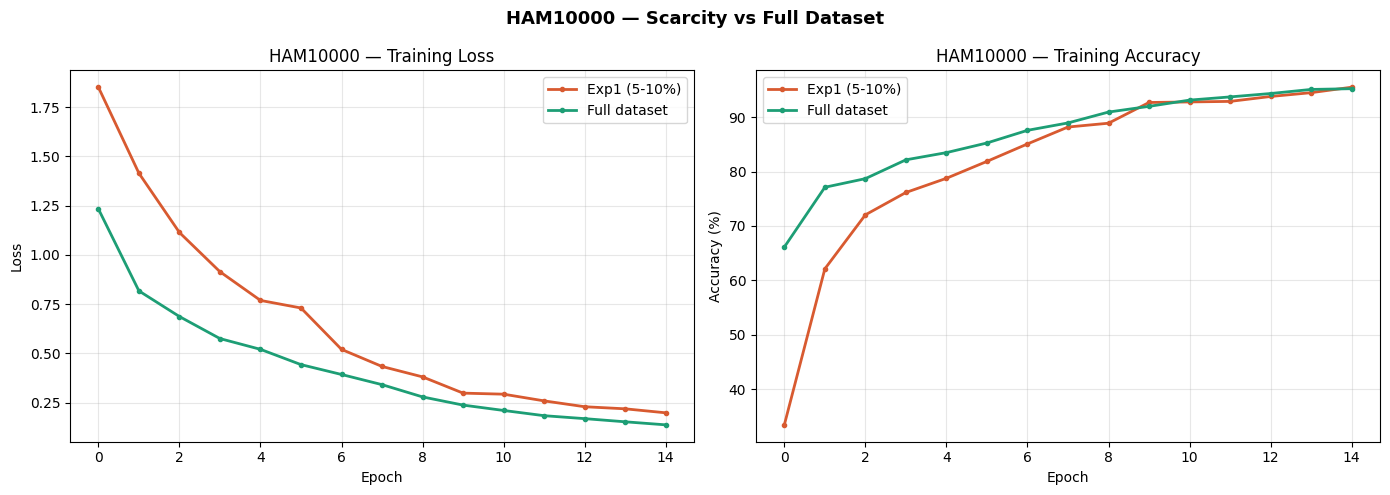


DAY 6 COMPLETE ✓
  HAM Exp1 — Accuracy : 77.59%
  HAM Exp1 — Top-5    : 94.8%
  HAM Full — Accuracy : 87.52%
  HAM Full — Top-5    : 99.5%

  Scarcity Gap:
    Accuracy : 9.93%
    Top-5    : 4.7%

  Next → Day 7: ZebraMap baseline (Exp 4)


In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, color='#D85A30',
             linewidth=2, marker='o', markersize=3,
             label='Exp1 (5-10%)')
axes[0].plot(full_losses, color='#1D9E75',
             linewidth=2, marker='o', markersize=3,
             label='Full dataset')
axes[0].set_title('HAM10000 — Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, color='#D85A30',
             linewidth=2, marker='o', markersize=3,
             label='Exp1 (5-10%)')
axes[1].plot(full_accs, color='#1D9E75',
             linewidth=2, marker='o', markersize=3,
             label='Full dataset')
axes[1].set_title('HAM10000 — Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('HAM10000 — Scarcity vs Full Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/day6_ham10000_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save summary
summary = {
    "day"         : 6,
    "dataset"     : "HAM10000",
    "exp1_metrics": exp1_metrics,
    "full_metrics": full_metrics,
    "scarcity_gap": {
        "accuracy_gap": round(
            full_metrics['accuracy'] -
            exp1_metrics['accuracy'], 2),
        "top5_gap"    : round(
            full_metrics['top5_accuracy'] -
            exp1_metrics['top5_accuracy'], 2)
    },
    "status": "Day 6 complete"
}

with open('/kaggle/working/day6_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 55)
print("DAY 6 COMPLETE ✓")
print("=" * 55)
print(f"  HAM Exp1 — Accuracy : {exp1_metrics['accuracy']}%")
print(f"  HAM Exp1 — Top-5    : {exp1_metrics['top5_accuracy']}%")
print(f"  HAM Full — Accuracy : {full_metrics['accuracy']}%")
print(f"  HAM Full — Top-5    : {full_metrics['top5_accuracy']}%")
print(f"\n  Scarcity Gap:")
print(f"    Accuracy : {summary['scarcity_gap']['accuracy_gap']}%")
print(f"    Top-5    : {summary['scarcity_gap']['top5_gap']}%")
print(f"\n  Next → Day 7: ZebraMap baseline (Exp 4)")